In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Import data

In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


This is a regressor problem

In this we can try to predict Average score or say Total score
Or even single subject score using other features

Here we will predict Math score using other features (gender, race, parental level of education, lunch, test preparation course, reading score, writing score) as independent variables and math score as dependent variable

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X = df.drop('math score',axis=1)
y = df['math score']


# Suppose given maths score i have to predict the average
# df['Average'] = (df['reading score']+ df['writing score'] + df['math score'])/3
# df.drop(['reading score','writing score'],axis=1, inplace=True)
# X = df.drop('Average',axis=1)
# y = df['Average']

In [6]:
X.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [7]:
y.head(2)

0    72
1    69
Name: math score, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((800, 7), (200, 7), (800,), (200,))

In [10]:
categorical_features = X.select_dtypes(include='O').columns
numeric_features = X.select_dtypes(exclude='O').columns

print("Numerical features : ", numeric_features)
print("Categorical features : ", categorical_features)


Numerical features :  Index(['reading score', 'writing score'], dtype='object')
Categorical features :  Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [11]:
# Create Column Transformer with 3 types of transformers
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
onehot_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('StandardScaler', numeric_transformer, numeric_features),
        ('OneHotEncoder', onehot_transformer, categorical_features)
    ],
    remainder='passthrough'  
)


In [12]:
preprocessor

,transformers,"[('StandardScaler', ...), ('OneHotEncoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [13]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [15]:
def evaluate_model(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    rmse = np.sqrt(mse)
    return mae, mse, rmse, r2

In [16]:
from catboost import CatBoostRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'XGBoost' : XGBRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'CatBoost':CatBoostRegressor(verbose=False)
}

print(list(models.keys()))
print(list(models.values()))

['Linear Regression', 'Lasso', 'Ridge', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'AdaBoost', 'CatBoost']
[LinearRegression(), Lasso(), Ridge(), KNeighborsRegressor(), DecisionTreeRegressor(), RandomForestRegressor(), XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...), AdaBoostRegressor(), 

In [18]:
model_list = []
r2_list =[]

metrics = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mae_train, mse_train, rmse_train, r2_train = evaluate_model(y_train, y_train_pred)
    mae_test, mse_test, rmse_test, r2_test = evaluate_model(y_test, y_test_pred)

    model_list.append(list(models.keys())[i])
    r2_list.append(r2_test)

    metrics.append({
        'Model': list(models.keys())[i],
        'MAE': mae_test,
        'MSE': mse_test,
        'RMSE': rmse_test,
        'R2 Score': r2_test
    })

    print(f'{list(models.keys())[i]} Model Evaluation')
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(rmse_train))
    print("- Mean Absolute Error: {:.4f}".format(mae_train))
    print("- R2 Score: {:.4f}".format(r2_train))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(rmse_test))
    print("- Mean Absolute Error: {:.4f}".format(mae_test))
    print("- R2 Score: {:.4f}".format(r2_test))
    
    print('='*35)
    print('\n')

Linear Regression Model Evaluation
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso Model Evaluation
Model performance for Training set
- Root Mean Squared Error: 6.5925
- Mean Absolute Error: 5.2053
- R2 Score: 0.8072
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5173
- Mean Absolute Error: 5.1557
- R2 Score: 0.8254


Ridge Model Evaluation
Model performance for Training set
- Root Mean Squared Error: 5.3235
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3936
- Mean Absolute Error: 4.2125
- R2 Score: 0.8805


KNN Model Evaluation
Model performance for Training set
- Root Mean Squared Error: 5.5719
- Mean Absolute Error:

In [19]:
# pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)
results = pd.DataFrame({
    'Model': model_list,
    'R2 Score': r2_list
})
results.sort_values(by='R2 Score', ascending=False)

full_results_df = pd.DataFrame(metrics).sort_values(by='R2 Score', ascending=False)

In [20]:
results.head()

,Model,R2 Score
0,Linear Regression,0.880433
1,Lasso,0.825447
2,Ridge,0.880450
3,KNN,0.777262
4,Decision Tree,0.704362


In [21]:
full_results_df.head()

,Model,MAE,MSE,RMSE,R2 Score
2,Ridge,4.212527,29.091086,5.393615,0.880450
0,Linear Regression,4.214763,29.095170,5.393994,0.880433
7,AdaBoost,4.636294,35.575621,5.964530,0.853802
8,CatBoost,4.631211,36.436822,6.036292,0.850263
5,Random Forest,4.707569,36.507770,6.042166,0.849971


Selecting linear regresion because of max r2 score

In [22]:
linear_regressor = LinearRegression(fit_intercept=True)
linear_regressor.fit(X_train,y_train)
y_pred = linear_regressor.predict(X_test)

r2score = r2_score(y_test,y_pred)
print('R2 score is :', r2score)

R2 score is : 0.8804332983749564


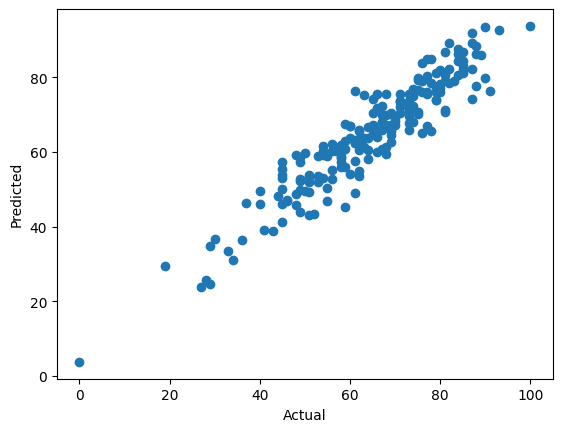

In [23]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

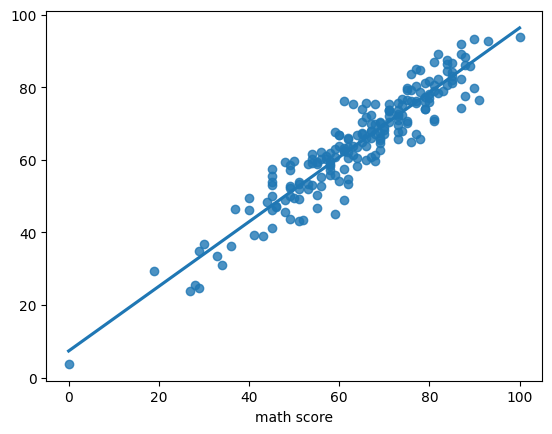

In [24]:
sns.regplot(x=y_test,y=y_pred,ci=None);

In [25]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
